<a href="https://colab.research.google.com/github/tinawanggg/Wang_DSPN_S26/blob/master/book/exercises/13_resampling-methods.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Exercise 13:  Resampling methods

This homework assignment is designed to give you practice with bootstrapping and permutation tests.

You will need to download the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file from the *Homework/hcp_data* folder in the class GitHub repository.

This data is a portion of the [Human Connectome Project database](http://www.humanconnectomeproject.org/). It provides measures of cognitive tasks and brain morphology measurements from 1206 participants. The full description of each variable is provided in the **HCP_S1200_DataDictionary_April_20_2018.csv** file in the *Homework/hcp_data* folder in the class GitHub repository.

---
## 1. Loading & Visualizing the Data (1 point)

Use the `setwd` and `read.csv` functions to load data from the **unrestricted_trimmed_1_7_2020_10_50_44.csv** file.

(a) Using the tidyverse tools, create a new dataframe `d1` that only includes the subject ID (`Subject`), gender (`Gender`, self reported at time of data collection), Flanker Task performance (`Flanker_Unadj`), total intracranial volume (`FS_IntraCranial_Vol`), total white matter volume (`FS_Tot_WM_Vol`), and total grey matter volume (`FS_Total_GM_Vol`) variables and remove all _na_ values.

Use the `head` function to look at the first few rows of each data frame.

In [2]:
# WRITE YOUR CODE HERE
library(tidyverse)
hcp_data <- read.csv("unrestricted_trimmed_1_7_2020_10_50_44.csv")

d1 <- hcp_data %>%
  select(Subject,
         Gender,
         Flanker_Unadj,
         FS_IntraCranial_Vol,
         FS_Tot_WM_Vol,
         FS_Total_GM_Vol) %>%
  drop_na()

head(d1)

,Subject,Gender,Flanker_Unadj,FS_IntraCranial_Vol,FS_Tot_WM_Vol,FS_Total_GM_Vol
,<int>,<chr>,<dbl>,<dbl>,<int>,<int>
1,100206,M,130.42,1864518,543134,807245
2,100307,F,112.56,1512540,407292,664124
3,100408,M,121.18,1684117,500417,726206
4,100610,M,126.53,1816044,512946,762308
5,101006,F,101.85,1437868,429449,579632
6,101107,M,107.04,1512727,416995,665024


(b) Plot grey matter volume (x axis) against intracranial volume (y axis) and Gender (point color).

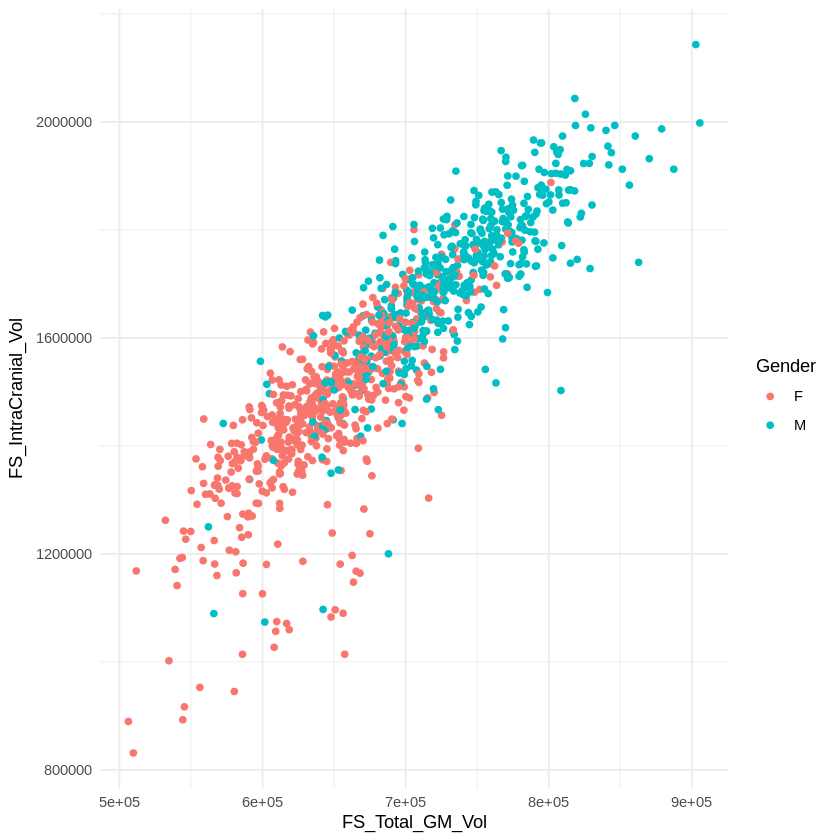

In [3]:
# WRITE YOUR CODE HERE
ggplot(d1, aes(x = FS_Total_GM_Vol, y = FS_IntraCranial_Vol, color = Gender)) +
  geom_point() +
  theme_minimal()

What patterns do you observe in the scatter plot?

> *There is a clear, strong positive correlation between grey matter volume and intracranial volume. The females are more concentrated in the lower left, suggesting that they have smaller grey matter and smaller intracranial volumes. The males are more concentrated in the upper right, suggesting that they have larger grey matter and larger intracranial volumes.*

---
## 2. Logistic classifier (2 points)

We want to try predicting gender using the neural data you have loaded.

(a) Run a logistic regression model to predict gender from total white matter volume, total grey matter volume, and intracranial volume.

In [4]:
# WRITE YOUR CODE HERE
d1$Gender <- as.factor(d1$Gender)

log_model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
                 data = d1,
                 family = binomial)

summary(log_model)


Call:
glm(formula = Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol, 
    family = binomial, data = d1)

Coefficients:
                      Estimate Std. Error z value Pr(>|z|)    
(Intercept)         -2.262e+01  1.347e+00 -16.787  < 2e-16 ***
FS_Tot_WM_Vol        2.140e-06  3.059e-06   0.699    0.484    
FS_Total_GM_Vol      1.959e-05  3.145e-06   6.229 4.70e-10 ***
FS_IntraCranial_Vol  5.020e-06  1.177e-06   4.263 2.01e-05 ***
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

(Dispersion parameter for binomial family taken to be 1)

    Null deviance: 1534.13  on 1112  degrees of freedom
Residual deviance:  919.85  on 1109  degrees of freedom
AIC: 927.85

Number of Fisher Scoring iterations: 5


Which factors are significantly associated with gender?

> *FS_Total_GM_Vol and FS_IntraCranial_Vol are significantly associated with gender (having a p-value of 4.70e-10 and 2.01e-05, respectively). FS_Tot_WM_Vol is not significantly associated with gender.*

(b) Estimate the prediction accuracy of your model (Note: this is the training set accuracy). Set your prediction threshold to 0.5.

In [5]:
# WRITE YOUR CODE HERE
predicted_probs <- predict(log_model, type = "response")

predicted_gender <- ifelse(predicted_probs >= 0.5, "M", "F")

conf_matrix <- table(Predicted = predicted_gender, Actual = d1$Gender)
print(conf_matrix)

accuracy <- mean(predicted_gender == d1$Gender)
print(accuracy)

         Actual
Predicted   F   M
        F 516 110
        M  90 397
[1] 0.8203055


What is the prediction accuracy for gender from the full model?

>*The prediction accuracy is 0.8203 or 82.03%. The model correctly classified about 82% of participants.*
>

---
## 3. Bootstrapped accuracy (3 points)

Use bootstrapping to estimate the confidence interval for your model's prediction accuracy. Plot a histogram of the bootstrapped accuracies, and estimate the confidence interval using the standard deviation of the bootstrap distribution.



ORDINARY NONPARAMETRIC BOOTSTRAP


Call:
boot(data = d1, statistic = boot.fn, R = 1000)


Bootstrap Statistics :
     original        bias    std. error
t1* 0.8203055 -0.0008086253  0.01248389


[1] 0.7950284

[1] 0.8439653

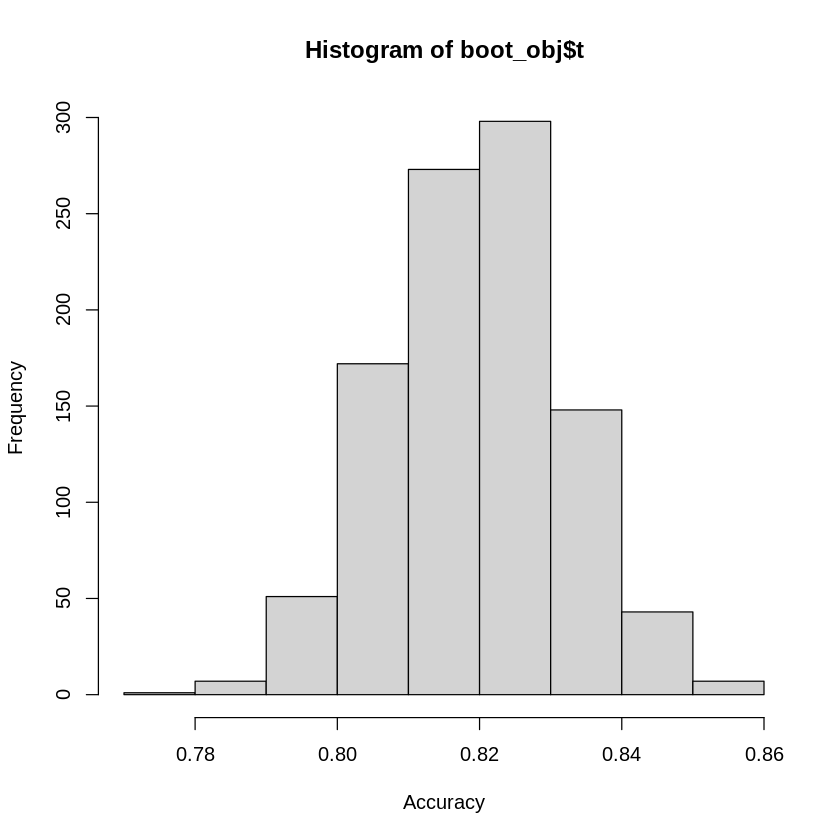

In [6]:
# WRITE YOUR CODE HERE
library(boot)

boot.fn <- function(data, index){
  model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
               data = data, subset = index, family = binomial)
  preds <- ifelse(predict(model, type = "response") >= 0.5, "M", "F")
  return(mean(preds == data$Gender[index]))}

boot_obj <- boot(d1, boot.fn, R = 1000)
print(boot_obj)

hist(boot_obj$t, xlab = "Accuracy")

# Lower and upper bounds of 95% CI
mean(boot_obj$t) - 1.96 * sd(boot_obj$t)
mean(boot_obj$t) + 1.96 * sd(boot_obj$t)

How robust is the prediction accuracy of the full model?

> *The output suggests that the bias is -0.0005184187, which is really low, so it suggests that the prediction accuracy is rather robust. The confidence interval is also relatively narrow (from 79.6% to 84.3%), suggesting that the original 82% prediction accuracy is reliable.*
>

---
## 4. Permutation test for grey matter effects (3 points)

Now run a permutation test, with 1000 iterations, to evaluate how much grey matter volume contributes to the prediction accuracy. Compare the prediction accuracy of the full (unpermuted) model with the distribution of accuracies obtained when the grey matter volume variable is permuted, using a histogram (Hint: use the `abline` function to show the original accuracy on the histogram).

[1] 0

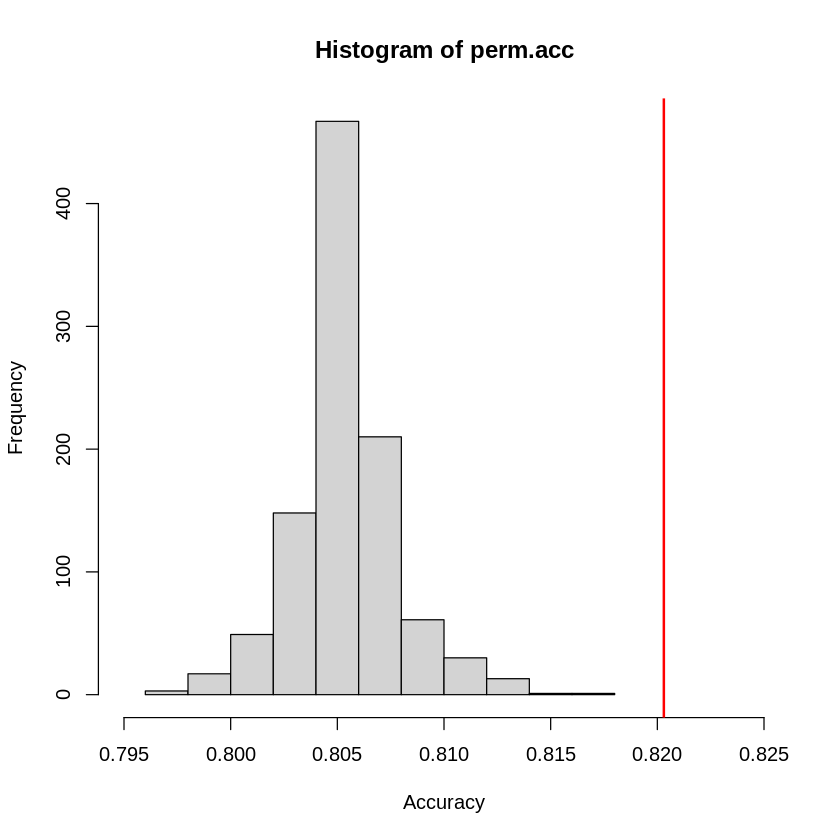

In [14]:
# WRITE YOUR CODE HERE
permD1 <- d1

R <- 1000

original_acc <- 0.8203055
perm.acc <- matrix(NA, nrow = R, ncol = 1)

for (i in 1:R){
  permD1$FS_Total_GM_Vol <- d1$FS_Total_GM_Vol[sample(nrow(d1))]
  perm.model <- glm(Gender ~ FS_Tot_WM_Vol + FS_Total_GM_Vol + FS_IntraCranial_Vol,
                    data = permD1, family = binomial)
  perm.preds <- ifelse(predict(perm.model, type = "response") >= 0.5, "M", "F")
  perm.acc[i,] <- mean(perm.preds == d1$Gender)
}

hist(perm.acc, xlab = "Accuracy", xlim = c(0.795, 0.825))
abline(v = original_acc, col = "red", lwd = 2)

mean(perm.acc >= original_acc)

How much does the grey matter volume influence the prediction accuracy of the model?

> *Grey matter volume influences the model's prediction accuracy to a small but significant extent. As seen by the abline, in comparison to the original prediction accuracy, removing grey matter volume consistently and reliably drops model performance.*
>

---
## 5. Reflection (1 point)

Differentiate the bootstrap from a permutation test. Describe each and explain when each is appropriate.

> *The bootstrap resamples the data with replacement to estimate uncertainty around a statistic (e.g., confidence intervals), while a permutation test shuffles a variable of interest to generate a null distribution and assess whether its relationship with the outcome is statistically significant.*

>*The bootstrap is appropriate to use when you want to estimate the uncertainty or reliability of an estimate without making strong distributional assumptions. A permutation test is appropriate to use when you want to test whether a specific variable has a statistically significant relationship with the outcome.*

**DUE:** 11:59pm EST, March 24, 2026

**IMPORTANT** Did you collaborate with anyone on this assignment? If so, list their names here.
> *N/A*

**GenAI Utilization** Did you utilize any generative AI tools on this assignment? If so, please list the item and the paste respective prompt you used.